# Regret

- **Load pipeline & data**  
  - Loads your trained pipeline and training DataFrame.  
  - Grabs exact feature columns and predicted metric names.  

- **Exogenous factors**  
  - Treats any column named like `group_<N>` with `N ≥ 48` as exogenous (fixed, not controllable).  
  - Builds scenarios = every unique combination of these exogenous columns (each combo = one “future”).  

- **Narratives (objective sets)**  
  - Defines goals, e.g. maximize production and minimize cost.  

- **Performance setup**  
  - Ensures XGBoost (if present) runs with multi-threaded prediction for speed.  

- **Optimization**  
  - Calls `optimise(...)` on decision variables (all features except exogenous).  
  - Evaluates policies under all scenarios, aggregates with mean (or worst).  
  - Inside `optimise`:  
    - Predicts all scenarios in one batch per generation (much faster).  
    - Uses all CPU cores.  
    - Averages (or worst-cases) results to get one score per policy.  
  - Keeps the **Pareto set** of best trade-offs (e.g., more production, less cost).  

- **Scoring policies**  
  - Tests each candidate across all futures.  
  - Scores = aggregated (mean or worst) across scenarios.  

- **Post-optimization analysis**  
  - **Utopia**: best value per metric within a narrative’s Pareto set.  
  - **Worst**: model’s worst value aggregated across futures.  
  - **Regret tables**: distance from utopia using:  
    - Absolute  
    - Proportional (% of utopia)  
    - Range-normalized (% of utopia–worst span)  

- **Memory handling**  
  - If memory is tight, processes futures in chunks (still batched).  
  - After optimization:  
    - Predicts Pareto policies again (averaged across scenarios).  
    - Computes utopia and worst.  
    - Calculates three regret views (absolute, proportional, range-normalized).  


In [1]:
# =========================================================================== #
# Scenario-aggregated optimisation + regrets (Notebook/Script)
# - Uses exogenous scenarios from unique combinations of group_<N> where N >= 48
# - Optimises with multi-scenario aggregation (mean) and aligns regret math
# - **Batched scenario predict** happens inside optimise() (v3.1 utils)
# - **Multi-threaded XGBoost predict** enabled via set_estimator_threads()
# =========================================================================== #

import os
import re
from pathlib import Path
from typing import Dict

import joblib
import numpy as np
import pandas as pd
from IPython.display import display

# Import utils 
from utils.narrative_profiles_optimization_utils import (
    optimise,
    set_estimator_threads,
)

# ---- Paths, model, reference data -------------------------------------------
SCRIPT_DIR_PATH = os.getcwd()
TRAINED_MODELS_DIR = Path(SCRIPT_DIR_PATH) / "trained_models"
MODEL_PATH = TRAINED_MODELS_DIR / "xgb_pipeline_5.3_without_health_without_consSavings.pkl"

pipeline = joblib.load(MODEL_PATH)

full_df = pd.read_parquet(
    TRAINED_MODELS_DIR / "xgb_pipeline_5.3_without_health_without_consSavings_training_df_cleaned.parquet"
)

feature_cols = list(pipeline.feature_names_in_)
X_ref = full_df[feature_cols]

# Metrics (must match model's predict() column order)
train_metrics = [
    "emission_total",
    "emission_avg_last_five_years",
    "production_total",
    "production_cost_total",
    "technical_cost",
    "air_pollution",

]

# Ensure multi-threaded predict for XGBoost (harmless if not present)
set_estimator_threads(pipeline)

# ---- Exogenous scenarios from unique group_>=48 combinations ----------------
def get_exogenous_group_cols(feature_cols, min_idx=48):
    """
    Return feature columns that look like group_<num>* where num >= min_idx.
    Matches: group_48, group_48_xxx, group_99_something, etc.
    """
    rx = re.compile(r"^group_(\d+)(?:_|$)")
    out = []
    for c in feature_cols:
        m = rx.match(c)
        if m and int(m.group(1)) >= min_idx:
            out.append(c)
    return out

EXOG_COLS = get_exogenous_group_cols(feature_cols, min_idx=48)
if not EXOG_COLS:
    raise ValueError("No exogenous columns found: expected 'group_<N>' with N >= 48.")

FREE_VARS = [c for c in feature_cols if c not in EXOG_COLS]
if len(FREE_VARS) == 0:
    raise ValueError(
        "All features are exogenous (group_>=48). No decision variables to optimize."
    )

# Build scenarios from unique EXOG_COLS combos present in X_ref

scenario_rows = (
    X_ref.drop_duplicates(subset=EXOG_COLS, keep="first")
    # .head(100)  # ← uncomment to cap number of scenarios for speed
)

SCENARIOS = []
for _, row in scenario_rows.iterrows():
    SCENARIOS.append({c: float(row[c]) for c in EXOG_COLS})

print(f"[scenarios] Built {len(SCENARIOS)} scenarios from {len(EXOG_COLS)} exogenous cols (group_>=48).")

# Multi-scenario controls
SCENARIO_MODE = "aggregate"   # "aggregate" or "stack"
SCENARIO_AGG  = "mean"        # "mean" or "worst" (min-space)
SCENARIO_CHUNK = 0            # set >0 to process scenarios in chunks (e.g., 32) for memory control

# ---- Narratives config -------------------------------------------------------
narratives_cfg = {
    "IndustryEnergyInvestment": [
        ("production_total", "max"),
        ("production_cost_total", "min"),
    ],
    "EmissionsReduction": [
        ("emission_total", "min"),
        ("emission_avg_last_five_years", "min"),
    ],
    "PlaceToLive": [
        ("air_pollution", "max"),
        # ("consumer_savings","max"),
        # ("technical_cost", "min"),
    ],
}

# ---- Helper: coerce optimiser output ----------------------------------------
def _ensure_numeric_schema(data_like, feature_cols):
    if isinstance(data_like, pd.DataFrame):
        df = data_like.copy()
    elif isinstance(data_like, pd.Series):
        df = data_like.to_frame().T
    elif isinstance(data_like, (list, tuple)) and data_like and isinstance(data_like[0], dict):
        df = pd.DataFrame(data_like)
    else:
        arr = np.asarray(data_like)
        if arr.ndim == 1:
            arr = arr.reshape(1, -1)
        elif arr.ndim != 2:
            raise ValueError(f"Unsupported optimiser output shape: {arr.shape}")
        df = pd.DataFrame(arr)
    if list(df.columns) != feature_cols:
        if len(df.columns) == len(feature_cols) and not all(isinstance(c, str) for c in df.columns):
            df.columns = feature_cols
        df = df.reindex(columns=feature_cols)
    if df.empty:
        raise AssertionError("Empty Pareto set after coercion")
    df = df.astype("float32")
    if df.isna().any().any():
        bad = df.columns[df.isna().any()].tolist()
        raise ValueError(f"NaNs present in features: {bad[:10]} ...")
    if not np.isfinite(df.to_numpy()).all():
        raise ValueError("Found ±inf values in features")
    return df

# ---- Aggregated prediction helper (aligns with aggregation='mean') ----------
def _clamp_df_to_scenario(X: pd.DataFrame, scenario: dict) -> pd.DataFrame:
    Xc = X.copy()
    for k, v in scenario.items():
        if k in Xc.columns:
            Xc[k] = v
    return Xc

def predict_aggregate_over_scenarios(pipeline, X: pd.DataFrame, scenarios: list, *, agg="mean"):
    preds = []
    for s in scenarios:
        Xs = _clamp_df_to_scenario(X, s)
        Ys = pd.DataFrame(pipeline.predict(Xs), columns=train_metrics)
        preds.append(Ys)
    if agg == "mean":
        return sum(preds) / len(preds)
    raise NotImplementedError("Only mean aggregation implemented in this driver.")

# ---- Optimise per narrative across SCENARIOS (aggregate-mean) ---------------
pareto_policies: Dict[str, pd.DataFrame] = {}
pareto_scores:   Dict[str, pd.DataFrame] = {}

for name, objs in narratives_cfg.items():
    targets = [m for (m, _) in objs]
    goals   = [s for (_, s) in objs]

    X_p, F_p = optimise(
        pipeline,
        X_ref=X_ref,
        train_targets=train_metrics,
        targets=targets,
        goals=goals,
        n_gen=120,
        pop_size=300,
        n_restarts=1,                  # consider 1-2 restarts (more restarts = slower)
        scenario_sets=SCENARIOS,
        scenario_mode=SCENARIO_MODE,
        scenario_agg=SCENARIO_AGG,
        scenario_chunk=SCENARIO_CHUNK, # 0 or None = no chunking; set e.g. 32 to limit memory
        ensure_threaded_predict=True,  # enable threaded XGBoost predict
    )

    Xp_df = _ensure_numeric_schema(X_p, feature_cols)
    Ys_agg = predict_aggregate_over_scenarios(pipeline, Xp_df, SCENARIOS, agg="mean")

    pareto_policies[name] = Xp_df
    pareto_scores[name]   = Ys_agg

# ---- Utopia (per narrative, per its own objective metric) -------------------
utopia_vals = {
    name: {
        m: (pareto_scores[name][m].max() if s == "max" else pareto_scores[name][m].min())
        for (m, s) in narratives_cfg[name]
    }
    for name in narratives_cfg
}

# ---- Worst from model space (scenario-aggregated) ---------------------------
_pred_all = predict_aggregate_over_scenarios(pipeline, X_ref, SCENARIOS, agg="mean")

def worst_of(metric: str, goal: str) -> float:
    return _pred_all[metric].min() if goal == "max" else _pred_all[metric].max()

# ---- Regret helpers ---------------------------------------------------------
def regret_abs(achieved, utopia, goal):
    return (utopia - achieved) if goal == "max" else (achieved - utopia)

def regret_pct_utopia(achieved, utopia, goal):
    ra = regret_abs(achieved, utopia, goal)
    denom = abs(utopia) if abs(utopia) > 1e-12 else 1.0
    return ra / denom

def regret_range(achieved, utopia, worst, goal):
    ra = regret_abs(achieved, utopia, goal)
    span = (utopia - worst) if goal == "max" else (worst - utopia)
    return 0.0 if abs(span) < 1e-12 else ra / span

# ---- Build regret tables ----------------------------------------------------
def split_objs(objs):
    metrics = [m for (m, _) in objs]
    senses  = [s for (_, s) in objs]
    return metrics, senses

def aggregate_regrets(regrets, mode="mean"):
    r = np.asarray(regrets, float)
    if mode == "max": return float(r.max())     # conservative
    if mode == "l2":  return float(np.sqrt((r**2).mean()))  # RMS
    return float(r.mean())

rows_abs, rows_pct, rows_rng = [], [], []

for src_name in narratives_cfg.keys():
    src_mean = pareto_scores[src_name].mean(axis=0)  # mean over A's aggregated Pareto

    for eval_name, eval_objs in narratives_cfg.items():
        metrics, senses = split_objs(eval_objs)

        reg_abs_list, reg_pct_list, reg_rng_list = [], [], []
        for metric, goal in zip(metrics, senses):
            achieved = src_mean[metric]
            utopia   = utopia_vals[eval_name][metric]
            worst    = worst_of(metric, goal)

            reg_abs_list.append(regret_abs(achieved, utopia, goal))
            reg_pct_list.append(regret_pct_utopia(achieved, utopia, goal))
            reg_rng_list.append(regret_range(achieved, utopia, worst, goal))

        rows_abs.append(dict(Policy=src_name, Evaluated_as=eval_name,
                             Regret=aggregate_regrets(reg_abs_list, mode="mean")))
        rows_pct.append(dict(Policy=src_name, Evaluated_as=eval_name,
                             Regret=aggregate_regrets(reg_pct_list, mode="mean")))
        rows_rng.append(dict(Policy=src_name, Evaluated_as=eval_name,
                             Regret=aggregate_regrets(reg_rng_list, mode="mean")))

reg_abs = pd.DataFrame(rows_abs).pivot(index="Policy", columns="Evaluated_as", values="Regret")
reg_pct = pd.DataFrame(rows_pct).pivot(index="Policy", columns="Evaluated_as", values="Regret")
reg_rng = pd.DataFrame(rows_rng).pivot(index="Policy", columns="Evaluated_as", values="Regret")

# ---- Display ----------------------------------------------------------------
fmt_abs = {n: "{:+,.2f}" for n in reg_abs.columns}
fmt_pct = {n: "{:+.1%}"  for n in reg_pct.columns}
fmt_rng = {n: "{:+.1%}"  for n in reg_rng.columns}

print("\n### ABSOLUTE regret (averaged across objectives; units mixed, scenario-aggregated)")
display(reg_abs.style.format(fmt_abs).background_gradient(cmap="Reds"))

print("\n### PROPORTIONAL regret (vs utopia %, scenario-aggregated)")
display(reg_pct.style.format(fmt_pct).background_gradient(cmap="Oranges"))

print("\n### RANGE-NORMALISED regret (0–100 % of utopia–worst window, scenario-aggregated)")
display(reg_rng.style.format(fmt_rng).background_gradient(cmap="Purples"))

tbl = reg_rng
summary = pd.DataFrame({
    "WorstRegret": tbl.max(axis=1),
    "MeanRegret":  tbl.mean(axis=1),
}).round(2)

def highlight_min(s):
    is_min = s == s.min()
    return ['background-color: mediumseagreen; color: white' if v else '' for v in is_min]

display(
    summary.style
           .format("{:.1%}")
           .apply(highlight_min, subset=["WorstRegret", "MeanRegret"])
           .background_gradient(cmap="OrRd")
           .set_caption("Range-normalised regret (scenario-aggregated; 0 % = utopia, 100 % = model worst)")
)


[scenarios] Built 979 scenarios from 11 exogenous cols (group_>=48).

### ABSOLUTE regret (averaged across objectives; units mixed, scenario-aggregated)


Evaluated_as,EmissionsReduction,IndustryEnergyInvestment,PlaceToLive
Policy,,,
EmissionsReduction,+6.50,"+1,181,429,184.00",+11.28
IndustryEnergyInvestment,+853.71,"+461,122,880.00",+25.42
PlaceToLive,+326.80,"+288,020,160.00",+0.00



### PROPORTIONAL regret (vs utopia %, scenario-aggregated)


Evaluated_as,EmissionsReduction,IndustryEnergyInvestment,PlaceToLive
Policy,,,
EmissionsReduction,+0.5%,+28.6%,+18.0%
IndustryEnergyInvestment,+69.0%,+6.1%,+40.5%
PlaceToLive,+27.6%,+10.8%,+0.0%



### RANGE-NORMALISED regret (0–100 % of utopia–worst window, scenario-aggregated)


Evaluated_as,EmissionsReduction,IndustryEnergyInvestment,PlaceToLive
Policy,,,
EmissionsReduction,+0.5%,+72.0%,+19.2%
IndustryEnergyInvestment,+66.2%,+16.2%,+43.3%
PlaceToLive,+26.0%,+26.6%,+0.0%


,WorstRegret,MeanRegret
Policy,,
EmissionsReduction,72.0%,31.0%
IndustryEnergyInvestment,66.0%,42.0%
PlaceToLive,27.0%,18.0%


## Consensus

In [2]:
# ============================================
# Areas of Agreement – scenario-aggregated
# ============================================

from collections import defaultdict
import numpy as np, pandas as pd, re
import matplotlib.pyplot as plt
from typing import Dict
from IPython.display import display

from utils.narrative_profiles_optimization_utils import optimise, set_estimator_threads

# ---------- helpers ----------
def _ensure_numeric_schema(data_like, feature_cols):
    """Accept DF / Series / ndarray / list; return float32 DF with columns=feature_cols."""
    if isinstance(data_like, pd.DataFrame):
        df = data_like.copy()
    elif isinstance(data_like, pd.Series):
        df = data_like.to_frame().T
    else:
        arr = np.asarray(data_like)
        if arr.ndim == 1: arr = arr.reshape(1, -1)
        df = pd.DataFrame(arr)
    if list(df.columns) != feature_cols:
        if len(df.columns) == len(feature_cols) and not all(isinstance(c, str) for c in df.columns):
            df.columns = feature_cols
        df = df.reindex(columns=feature_cols)
    if df.empty: raise AssertionError("Empty candidate set after coercion")
    df = df.astype("float32")
    if df.isna().any().any(): raise ValueError("NaNs present in features")
    if not np.isfinite(df.to_numpy()).all(): raise ValueError("Found ±inf in features")
    return df

def _get_exogenous_group_cols(feature_cols, min_idx=48):
    rx = re.compile(r"^group_(\d+)(?:_|$)")
    out = []
    for c in feature_cols:
        m = rx.match(c)
        if m and int(m.group(1)) >= min_idx:
            out.append(c)
    return out

def _clamp_df_to_scenario(X: pd.DataFrame, scenario: dict) -> pd.DataFrame:
    Xc = X.copy()
    for k, v in scenario.items():
        if k in Xc.columns:
            Xc[k] = v
    return Xc

def predict_aggregate_over_scenarios(pipeline, X: pd.DataFrame, scenarios: list, *, agg="mean"):
    preds = []
    for s in scenarios:
        Xs = _clamp_df_to_scenario(X, s)
        Ys = pd.DataFrame(pipeline.predict(Xs), columns=train_metrics)
        preds.append(Ys)
    if agg == "mean":
        return sum(preds) / len(preds)
    raise NotImplementedError("Only mean aggregation implemented.")

# ---------- 0) Build scenarios if not present ----------
try:
    SCENARIOS  # reuse if already defined
except NameError:
    EXOG_COLS = _get_exogenous_group_cols(feature_cols, min_idx=48)
    if not EXOG_COLS:
        raise ValueError("No exogenous columns found: expected 'group_<N>' with N >= 48.")
    scenario_rows = X_ref.drop_duplicates(subset=EXOG_COLS, keep="first")
    SCENARIOS = [{c: float(row[c]) for c in EXOG_COLS} for _, row in scenario_rows.iterrows()]
    print(f"[scenarios] Built {len(SCENARIOS)} scenarios from {len(EXOG_COLS)} exogenous cols (group_>=48).")

# Thread XGBoost predict (harmless if non-XGB)
try:
    set_estimator_threads(pipeline)
except Exception:
    pass

SCENARIO_MODE  = "aggregate"  # "aggregate" or "stack"
SCENARIO_AGG   = "mean"       # "mean" or "worst"
SCENARIO_CHUNK = 0            # set e.g. 32 if memory is tight

# ---------- 1) Union of objectives across narratives (consistency check) ----------
metric_goal: Dict[str, str] = {}
for _, objs in narratives_cfg.items():
    for m, s in objs:
        if m in metric_goal and metric_goal[m] != s:
            raise ValueError(f"Conflicting sense for metric '{m}': {metric_goal[m]} vs {s}")
        metric_goal[m] = s
all_targets = list(metric_goal.keys())
all_goals   = [metric_goal[m] for m in all_targets]

# ---------- 2) Global multi-objective search (scenario-aggregated) ----------
pareto_X, _ = optimise(
    pipeline,
    X_ref=X_ref,
    train_targets=train_metrics,
    targets=all_targets,
    goals=all_goals,
    n_gen=160,
    pop_size=320,
    n_restarts=1,
    scenario_sets=SCENARIOS,
    scenario_mode=SCENARIO_MODE,
    scenario_agg=SCENARIO_AGG,
    scenario_chunk=SCENARIO_CHUNK,
    ensure_threaded_predict=True,
)
pareto_X = _ensure_numeric_schema(pareto_X, feature_cols)

# Get scenario-aggregated metrics (all train_metrics) for Pareto policies
pareto_F = predict_aggregate_over_scenarios(pipeline, pareto_X, SCENARIOS, agg="mean")
print("Global Pareto front (scenario-aggregated):", len(pareto_X), "policies")

# ---------- 3) Utopia per narrative (each narrative’s own aggregated Pareto set) ----------
utopia_vals: Dict[str, Dict[str, float]] = {}
for name, objs in narratives_cfg.items():
    t = [m for (m, _) in objs]
    g = [s for (_, s) in objs]
    Xn, _ = optimise(
        pipeline,
        X_ref=X_ref,
        train_targets=train_metrics,
        targets=t,
        goals=g,
        n_gen=120,
        pop_size=260,
        n_restarts=1,
        scenario_sets=SCENARIOS,
        scenario_mode=SCENARIO_MODE,
        scenario_agg=SCENARIO_AGG,
        scenario_chunk=SCENARIO_CHUNK,
        ensure_threaded_predict=True,
    )
    Xn = _ensure_numeric_schema(Xn, feature_cols)
    Fn_agg = predict_aggregate_over_scenarios(pipeline, Xn, SCENARIOS, agg="mean")
    utopia_vals[name] = {m: (Fn_agg[m].max() if s == "max" else Fn_agg[m].min()) for (m, s) in objs}

# ---------- 4) Worst values from model space (scenario-aggregated on X_ref) ----------
_pred_all = predict_aggregate_over_scenarios(pipeline, X_ref, SCENARIOS, agg="mean")
def worst_of(metric, goal):
    return _pred_all[metric].min() if goal == "max" else _pred_all[metric].max()

# ---------- 5) Range-normalised regret per narrative ----------
def regret_abs(ach, ut, goal):       return (ut - ach) if goal == "max" else (ach - ut)
def regret_range(ach, ut, worst, g):
    ra = regret_abs(ach, ut, g)
    span = (ut - worst) if g == "max" else (worst - ut)
    return 0.0 if abs(span) < 1e-12 else ra / span

reg_rng = pd.DataFrame(index=pareto_F.index)
for name, objs in narratives_cfg.items():
    vals = []
    for (m, s) in objs:
        ach   = pareto_F[m]                  # achieved metric on the global Pareto set (aggregated)
        ut    = utopia_vals[name][m]         # that narrative's utopia for m
        worst = worst_of(m, s)
        vals.append(ach.apply(lambda v: regret_range(v, ut, worst, s)))
    reg_rng[name] = pd.concat(vals, axis=1).mean(axis=1)  # unweighted mean across objectives

# ---------- 6) Consensus filter ----------
THR = 0.45  # e.g., every narrative loses ≤45% of its achievable performance
mask_agree = reg_rng.max(axis=1) <= THR
agree_X = pareto_X[mask_agree].reset_index(drop=True)
agree_F = pareto_F[mask_agree].reset_index(drop=True)

print(f"{len(agree_X)} policies satisfy the ≤{THR:.0%} regret rule")

# # Optional: quick peek
# try:
#     display(reg_rng.style.format("{:.1%}").background_gradient(cmap="Purples"))
# except Exception:
#     print(reg_rng)


Global Pareto front (scenario-aggregated): 320 policies
134 policies satisfy the ≤45% regret rule


In [3]:
# ---------- 5) Consensus filter ----------
THR = 0.25  # e.g., every narrative loses ≤60% of its achievable performance
mask_agree = reg_rng.max(axis=1) <= THR
agree_X = pareto_X[mask_agree]
agree_F = pareto_F[mask_agree]
print(f"{len(agree_X)} policies satisfy the ≤{THR:.0%} regret rule")

45 policies satisfy the ≤25% regret rule


In [ ]:
agree_X

In [ ]:
for col in agree_X.columns:
    print(col)

In [4]:
# Best point per narrative on the GLOBAL Pareto front (lowest mean range-regret)
def _best_points_on_pareto(pareto_F, narratives_cfg, utopia_vals, worst_of):
    out = {}
    for name, objs in narratives_cfg.items():
        cols = []
        for m, s in objs:
            ut = utopia_vals[name][m]
            w  = worst_of(m, s)
            ra = (ut - pareto_F[m]) if s == "max" else (pareto_F[m] - ut)
            span = (ut - w) if s == "max" else (w - ut)
            cols.append( ra / (span if abs(span) > 1e-12 else 1.0) )
        mean_regret = pd.concat(cols, axis=1).mean(axis=1)
        out[name] = pareto_F.loc[mean_regret.idxmin()]
    return out

best_pts = _best_points_on_pareto(pareto_F, narratives_cfg, utopia_vals, worst_of)


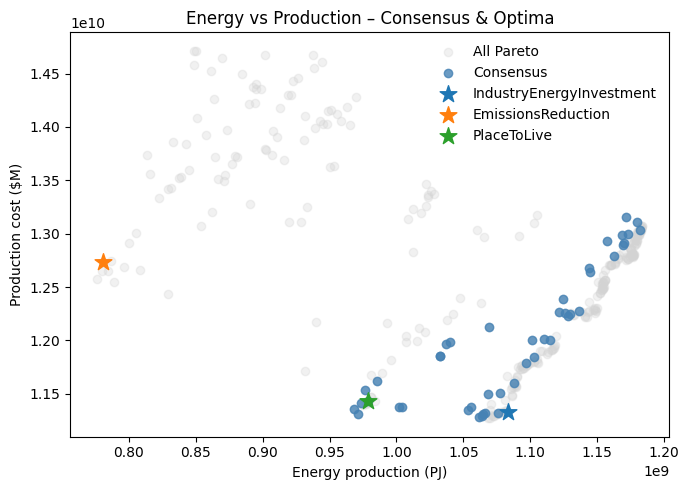

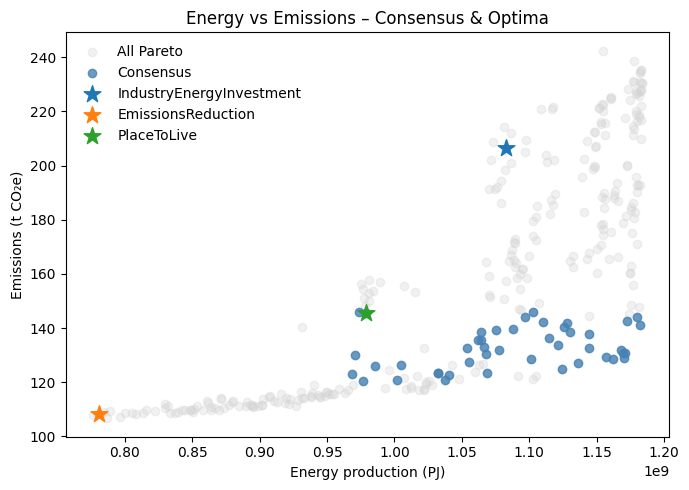

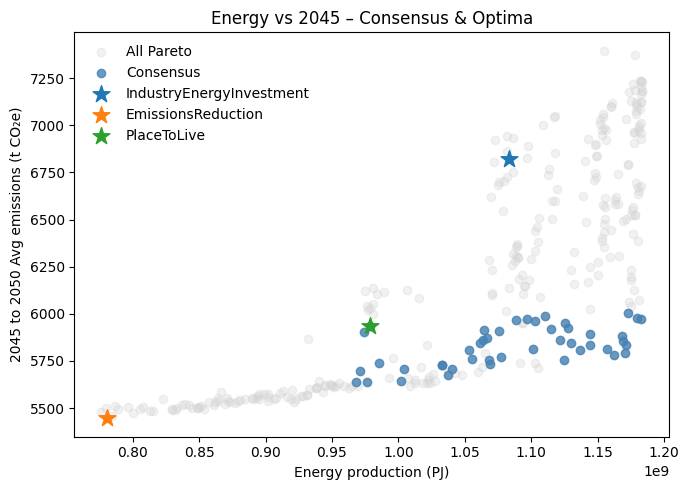

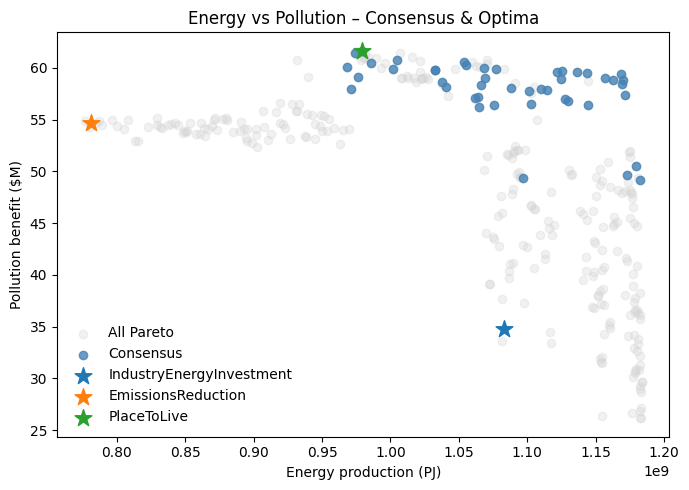

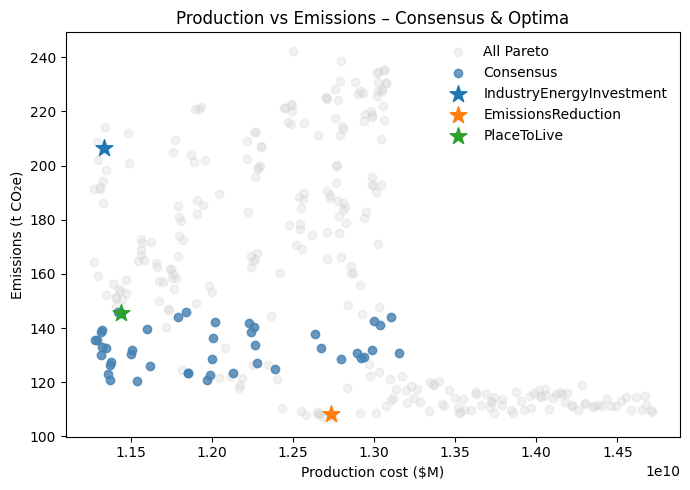

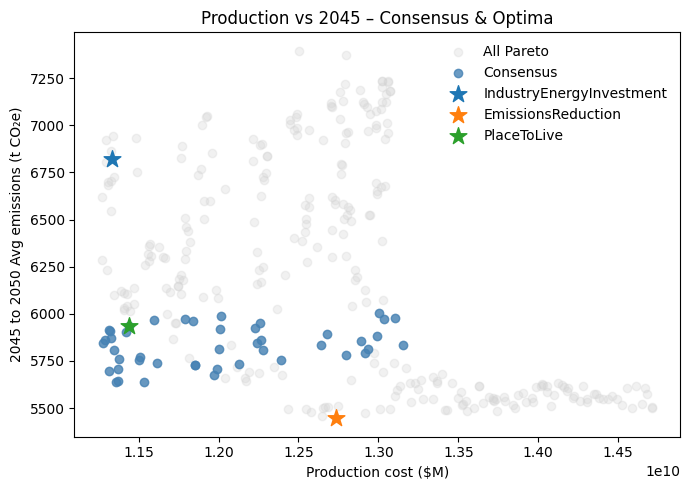

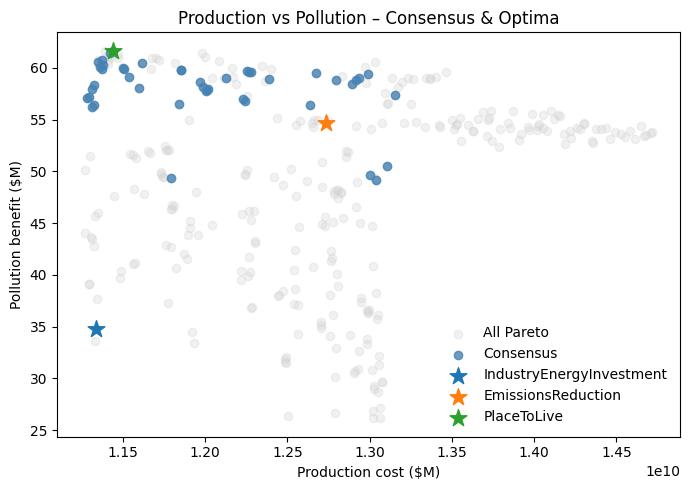

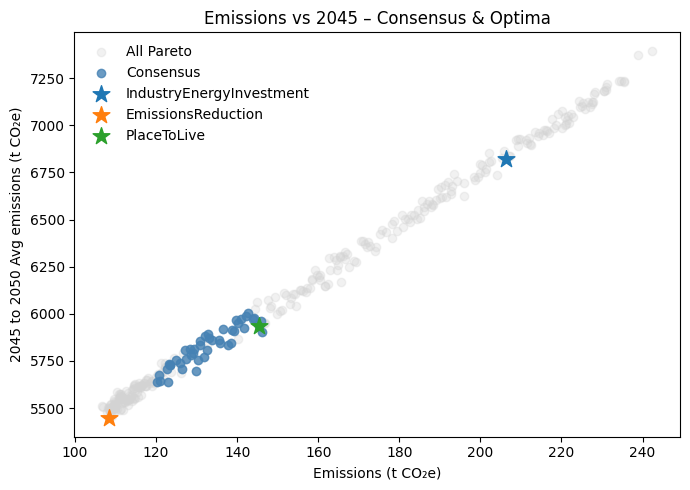

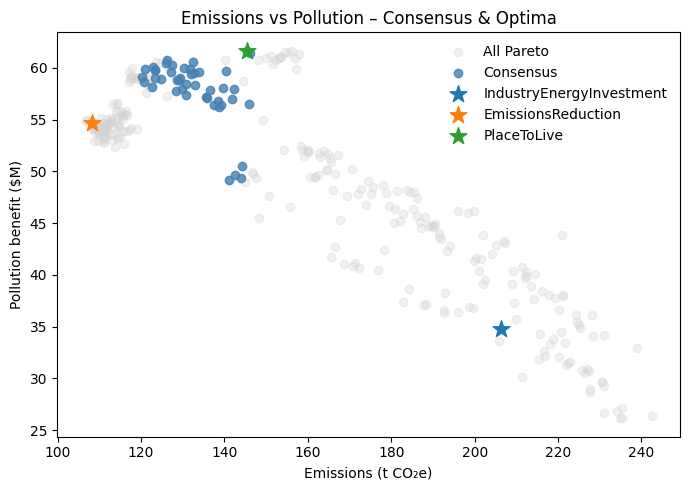

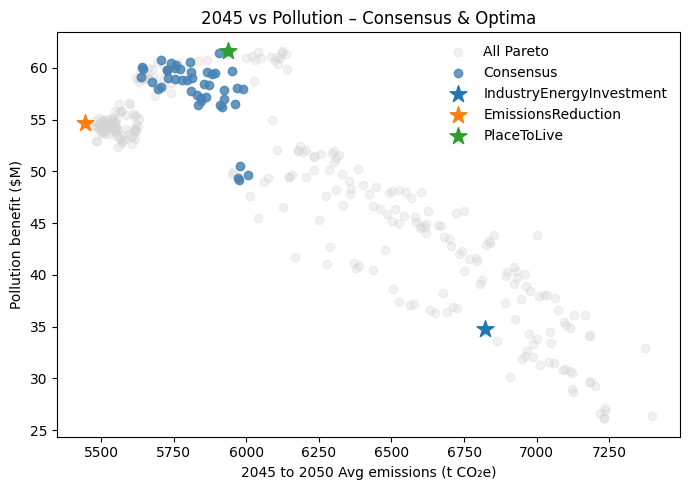

In [5]:
from itertools import combinations

# 1) Union of metrics in the order they appear in narratives_cfg
metrics_union = []
for _, objs in narratives_cfg.items():
    for m, _ in objs:
        if m not in metrics_union:
            metrics_union.append(m)

# 2) Nice labels (use a map, fall back to Title Case)
label_map = {
    "production_total": "Energy production (PJ)",
    "emission_total": "Emissions (t CO₂e)",
    "emission_avg_last_five_years": "2045 to 2050 Avg emissions (t CO₂e)",
    "production_cost_total": "Production cost ($M)",

    "air_pollution": "Pollution benefit ($M)"
}
def nice_label(m):  # fallback for any new metric you add later
    return m.replace("_", " ").title()

labels_list = [(m, label_map.get(m, nice_label(m))) for m in metrics_union if m in pareto_F.columns]

# 3) All metric pairs to plot (covers every objective in narratives_cfg)
pairs = list(combinations(labels_list, 2))

# 4) Plot loop (unchanged, now driven by 'pairs')
for (mx, lx), (my, ly) in pairs:
    plt.figure(figsize=(7, 5))
    plt.scatter(pareto_F[mx], pareto_F[my], color="lightgrey", alpha=0.3, label="All Pareto")
    plt.scatter(agree_F[mx],  agree_F[my],  color="steelblue", alpha=0.8, label="Consensus")
    for n, s in best_pts.items():
        plt.scatter(s[mx], s[my], marker="*", s=160, label=n)
    plt.xlabel(lx); plt.ylabel(ly)
    plt.title(f"{lx.split()[0]} vs {ly.split()[0]} – Consensus & Optima")
    plt.legend(frameon=False); plt.tight_layout(); plt.show()


In [ ]:
agree_X

### Rename agree_X column names

In [6]:
SCRIPT_DIR_PATH = os.getcwd()
ROOT_DIR_PATH = os.path.dirname(SCRIPT_DIR_PATH)
DATA_DIR_PATH = os.path.join(ROOT_DIR_PATH, "data")
MAPPING_DIR_PATH = os.path.join(DATA_DIR_PATH, "mapping")
SSP_DIR_PATH = os.path.join(DATA_DIR_PATH, "ssp")
TRAINING_DIR_PATH = os.path.join(DATA_DIR_PATH, "training")
CONFIG_DIR_PATH = os.path.join(ROOT_DIR_PATH, "config")

In [7]:
run_id="sisepuede_run_2025-08-28t15;29;22.344855"

In [9]:
SIMULATION_DIR_PATH = os.path.join(SSP_DIR_PATH, run_id)
print(SIMULATION_DIR_PATH)

e:\Current_2023\WI\work\ssp_louisiana\metamodel\data\ssp\sisepuede_run_2025-08-28t15;29;22.344855


In [10]:
TRANSFORMATIONS_CSV =  pd.read_csv(os.path.join(SIMULATION_DIR_PATH, "transformation_names_clean.csv"))
GROUPS_CSV =  pd.read_csv(os.path.join(SIMULATION_DIR_PATH, "VARIABLE_TRAJECTORY_GROUPS_L.csv"))

In [11]:
import re, pandas as pd

def build_map(t_src, g_src):
    t = t_src if isinstance(t_src, pd.DataFrame) else pd.read_csv(str(t_src))
    if not {"transformation_code","transformation_name"} <= set(t.columns):
        t = t.rename(columns={t.columns[0]:"transformation_code", t.columns[1]:"transformation_name"})
    g = g_src if isinstance(g_src, pd.DataFrame) else pd.read_csv(str(g_src))
    m = g.merge(t, on="transformation_code", how="left")
    m["name"] = (m["transformation_name"].astype(str)
                 .str.replace(r"^Default Value -\s*", "", regex=True)
                 .str.strip())
    return (m.dropna(subset=["name"])
             .drop_duplicates("variable_trajectory_group")
             .set_index("variable_trajectory_group")["name"].to_dict())

def rename_agree_X(df, gmap):
    pat, r = re.compile(r"^group_(\d+)_"), {}
    for c in df.columns:
        m = pat.match(c)
        if m:
            n = int(m.group(1))
            if n in gmap:
                r[c] = f"group_{n}_{gmap[n]}"
    return df.rename(columns=r), r


In [12]:

group_to_name = build_map(TRANSFORMATIONS_CSV, GROUPS_CSV)
agree_X_renamed, rename_dict = rename_agree_X(agree_X, group_to_name)


In [13]:
agree_X_renamed

,group_1_AGRC: Improve rice management,group_2_AGRC: Reduce supply chain losses,group_3_AGRC: Expand conservation agriculture,group_4_CCSQ: Increase direct air capture,group_5_ENTC: Reduce transmission losses,group_6_ENTC: Clean hydrogen,group_7_ENTC: 95% of electricity is generated by renewables in 2050,group_8_FGTV: Minimize leaks,group_9_FGTV: Maximize flaring,group_10_INEN: Maximize industrial energy efficiency,...,group_49_nemomod_entc,group_50_nemomod_enst_capital_cost_st,group_51_exports_enfu_pj_fuel,group_52_gdp_mmm_usd,group_53_population_gnrl,group_54_elasticity_scoe_enerdem_per,group_55_elasticity_trde_mtkm_to_gdp_freight,group_56_elasticity_trde_pkm_to_gdppc,group_57_elasticity_ippu,group_58_elasticity_ippu_product_use
3,0.266724,0.586607,0.468171,0.037184,0.952100,0.186355,0.969526,0.942208,0.090899,0.918578,...,0.174909,0.800519,0.061416,0.745356,0.031543,0.804460,0.938472,0.434559,0.087983,0.605523
32,0.272088,0.857055,0.760900,0.977233,0.948343,0.081237,0.995866,0.919367,0.095765,0.068655,...,0.825338,0.233753,0.982145,0.736144,0.947290,0.228526,0.474731,0.378151,0.230431,0.718992
36,0.022199,0.593506,0.282993,0.986539,0.945185,0.046863,0.951615,0.184231,0.776837,0.006533,...,0.960709,0.967913,0.002892,0.762949,0.332710,0.733607,0.217030,0.376864,0.562233,0.486635
67,0.168813,0.216405,0.004662,0.997875,0.505423,0.080201,0.981854,0.781651,0.044168,0.067722,...,0.781499,0.827756,0.114396,0.034405,0.306646,0.260730,0.878955,0.423599,0.611360,0.689298
73,0.786957,0.765544,0.526854,0.985994,0.986112,0.093042,0.978105,0.859614,0.056306,0.001741,...,0.959411,0.233415,0.786492,0.006267,0.023170,0.699316,0.428553,0.418985,0.389691,0.734242
91,0.171555,0.894103,0.163558,0.976108,0.994548,0.909894,0.979333,0.926751,0.054243,0.028743,...,0.970347,0.311077,0.786745,0.752296,0.186303,0.802963,0.869758,0.391648,0.567698,0.404182
96,0.045819,0.472086,0.477361,0.991483,0.953014,0.926262,0.978115,0.895401,0.789749,0.609813,...,0.808282,0.267116,0.833101,0.084436,0.796803,0.598961,0.588807,0.406061,0.597708,0.392796
101,0.261417,0.483766,0.760900,0.977078,0.949028,0.081237,0.995876,0.919303,0.141937,0.068655,...,0.826515,0.233753,0.982145,0.732981,0.950934,0.795820,0.474731,0.378151,0.230431,0.718992
102,0.227760,0.759136,0.197914,0.998271,0.512484,0.120552,0.979328,0.988254,0.082769,0.014771,...,0.964536,0.350355,0.051783,0.521438,0.308222,0.677872,0.822928,0.427205,0.566801,0.624589
119,0.203219,0.960180,0.247136,0.998366,0.948299,0.937453,0.993989,0.919297,0.040754,0.071585,...,0.741828,0.870291,0.320207,0.090330,0.775709,0.250658,0.789682,0.251980,0.491167,0.784193


## Consensus Policies Heatmap

In [14]:
# ================================
# Heatmap of lever intensities for agree_X
# Ordered by "High" frequency; prettier styling
# ================================

import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm
from matplotlib.patches import Patch
from typing import List, Tuple

# Global style tweaks
plt.rcParams["font.family"] = "DejaVu Sans"   # pretty, widely available
TEXT_GRAY = "#4a4a4a"

# ---- helper: find group_<N> with N < 48 ----
def get_lever_cols_lt48(columns: List[str], max_idx_exclusive: int = 48) -> List[str]:
    rx = re.compile(r"^group_(\d+)(?:_|$)")
    lever_cols = []
    for c in columns:
        m = rx.match(c)
        if m and int(m.group(1)) < max_idx_exclusive:
            lever_cols.append(c)
    # stable sort by numeric id then full name
    lever_cols.sort(key=lambda x: (int(re.match(r"^group_(\d+)", x).group(1)), x))
    return lever_cols

# ---- helper: bin to 0/1/2 = Low/Med/High ----
def bin_low_med_high(df: pd.DataFrame,
                     low_thr: float = 0.25,
                     high_thr: float = 0.75) -> np.ndarray:
    vals = df.to_numpy(dtype=float)
    vals = np.clip(vals, 0.0, 1.0)         # safety if outside [0,1]
    bins = np.zeros_like(vals, dtype=int)  # Low
    bins[(vals >= low_thr) & (vals < high_thr)] = 1  # Medium
    bins[vals >= high_thr] = 2                      # High
    return bins

# ---- helper: order rows by High, then Medium, then average value ----
def order_rows_by_intensity(Z: np.ndarray, M: pd.DataFrame) -> np.ndarray:
    high_cnt = (Z == 2).sum(axis=1)
    med_cnt  = (Z == 1).sum(axis=1)
    mean_val = M.to_numpy(dtype=float).mean(axis=1)
    # numpy.lexsort: last key is primary → use negatives for descending
    idx = np.lexsort((-mean_val, -med_cnt, -high_cnt))
    return idx

def plot_transformation_heatmap(agree_X: pd.DataFrame,
                                title: str = "Transformations in Pareto Frontier",
                                low_thr: float = 0.25,
                                high_thr: float = 0.75,
                                figsize: Tuple[int, int] = (16, 9)):
    if not isinstance(agree_X, pd.DataFrame) or agree_X.empty:
        raise ValueError("agree_X must be a non-empty DataFrame")

    # columns for levers
    lever_cols = get_lever_cols_lt48(list(agree_X.columns), max_idx_exclusive=48)
    if len(lever_cols) == 0:
        raise ValueError("No group_<N> columns with N < 48 found in agree_X.")

    # matrix: rows = levers, cols = policies
    M = agree_X[lever_cols].T  # shape (n_levers, n_policies)

    # bin to Low/Medium/High
    Z = bin_low_med_high(M, low_thr=low_thr, high_thr=high_thr)

    # order rows by intensity (High first)
    order = order_rows_by_intensity(Z, M)
    M = M.iloc[order, :]
    Z = Z[order, :]
    lever_cols_ordered = [lever_cols[i] for i in order]

  # PRETTY row labels: drop leading "group_<digits>_" (or "group_<digits>")
    row_labels = [re.sub(r"^group_\d+_?", "", name) for name in lever_cols_ordered]

    # colormap (Low, Medium, High)
    cmap = ListedColormap(["#9ADBC7", "#56B0B6", "#0B4C8A"])  # light teal, teal, deep blue
    norm = BoundaryNorm([-0.5, 0.5, 1.5, 2.5], cmap.N)

    # figure; reserve space on right for legend
    fig, ax = plt.subplots(figsize=figsize)
    fig.subplots_adjust(right=0.82)  # keep space for legend area

    im = ax.imshow(Z, aspect="auto", interpolation="nearest", cmap=cmap, norm=norm)

    # axes labels / ticks (all in gray + prettier font)
    ax.set_title(title, fontsize=16, pad=14, color=TEXT_GRAY)
    ax.set_xlabel("Optimal Portfolio Index", fontsize=12, color=TEXT_GRAY)
    ax.set_ylabel("", fontsize=12, color=TEXT_GRAY)

    # x ticks: 0..N-1 with reasonable step
    n_policies = Z.shape[1]
    step = max(1, n_policies // 20)
    ax.set_xticks(np.arange(0, n_policies, step))
    ax.set_xticklabels(np.arange(n_policies)[::step], rotation=0, color=TEXT_GRAY)

    # y ticks: lever labels without "group_"
    ax.set_yticks(np.arange(len(row_labels)))
    ax.set_yticklabels(row_labels, fontsize=9, color=TEXT_GRAY)

    # tick color for spines
    ax.tick_params(axis="x", colors=TEXT_GRAY)
    ax.tick_params(axis="y", colors=TEXT_GRAY)

    # thin gridlines between cells
    ax.set_xticks(np.arange(-0.5, n_policies, 1), minor=True)
    ax.set_yticks(np.arange(-0.5, len(row_labels), 1), minor=True)
    ax.grid(which="minor", color="white", linestyle="-", linewidth=0.6)
    ax.tick_params(which="minor", bottom=False, left=False)

    # legend outside on the right (no overlap)
    legend_elems = [
        Patch(facecolor=cmap(0), edgecolor="none", label="Low"),
        Patch(facecolor=cmap(1), edgecolor="none", label="Medium"),
        Patch(facecolor=cmap(2), edgecolor="none", label="High"),
    ]
    ax.legend(
        handles=legend_elems,
        title="Transformation\nIntensity",
        loc="upper left",
        bbox_to_anchor=(1.01, 1.0),  # outside the axes
        borderaxespad=0.0,
        frameon=False,
        title_fontsize=11,
    )

    plt.tight_layout()
    plt.show()



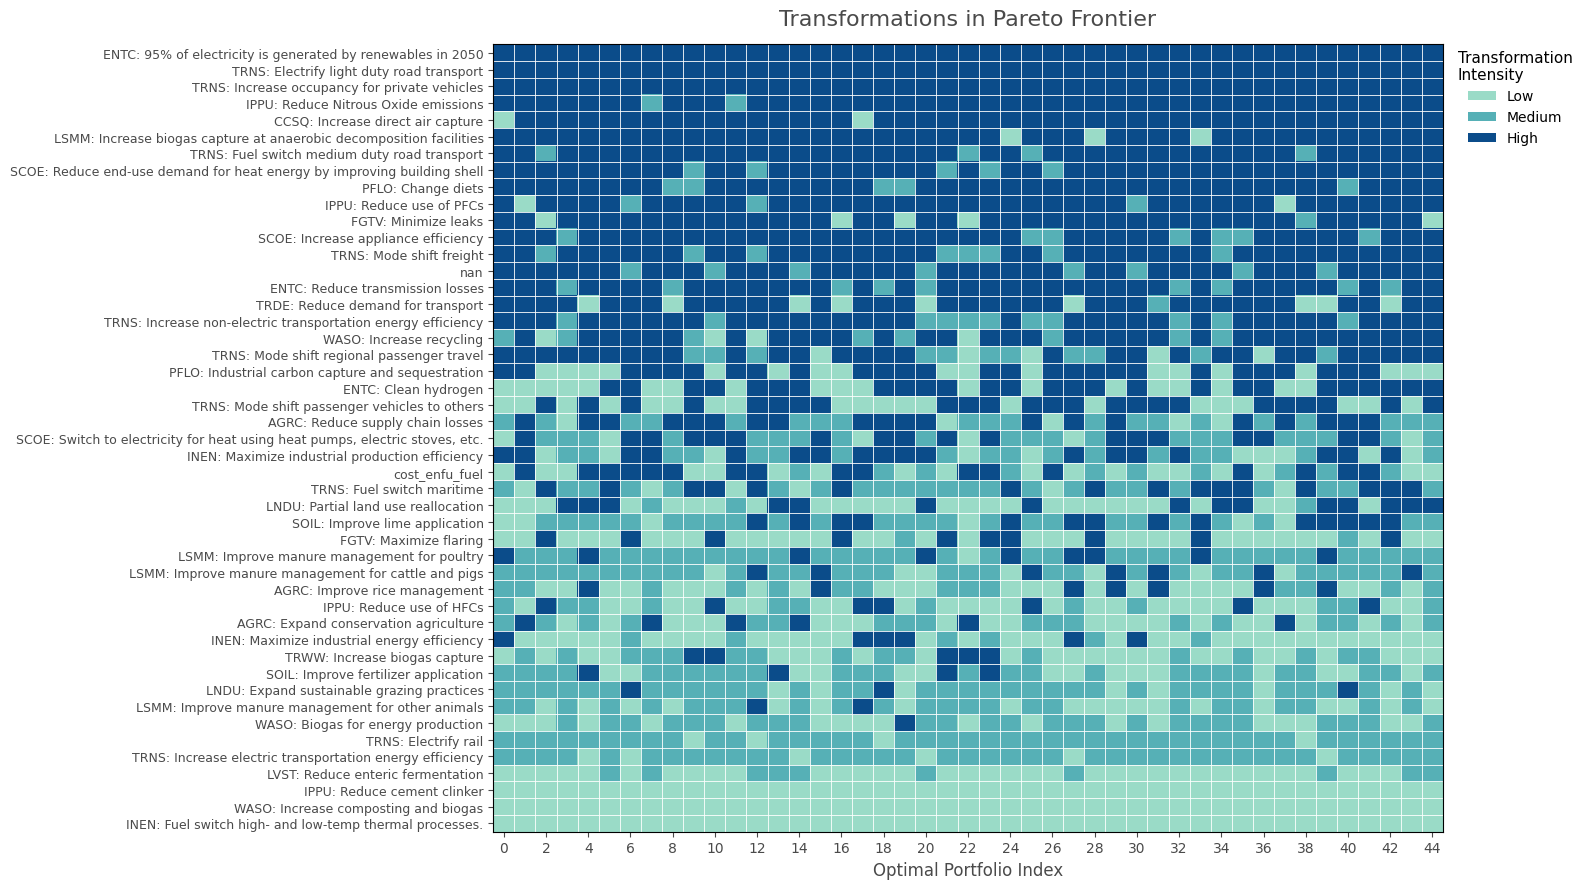

In [15]:
# ---- call it ----
agree_X_renamed = agree_X_renamed.reset_index(drop=True)  # clean column index
plot_transformation_heatmap(agree_X_renamed)

### Consensus vs. All-Scenarios Policy Comparison 

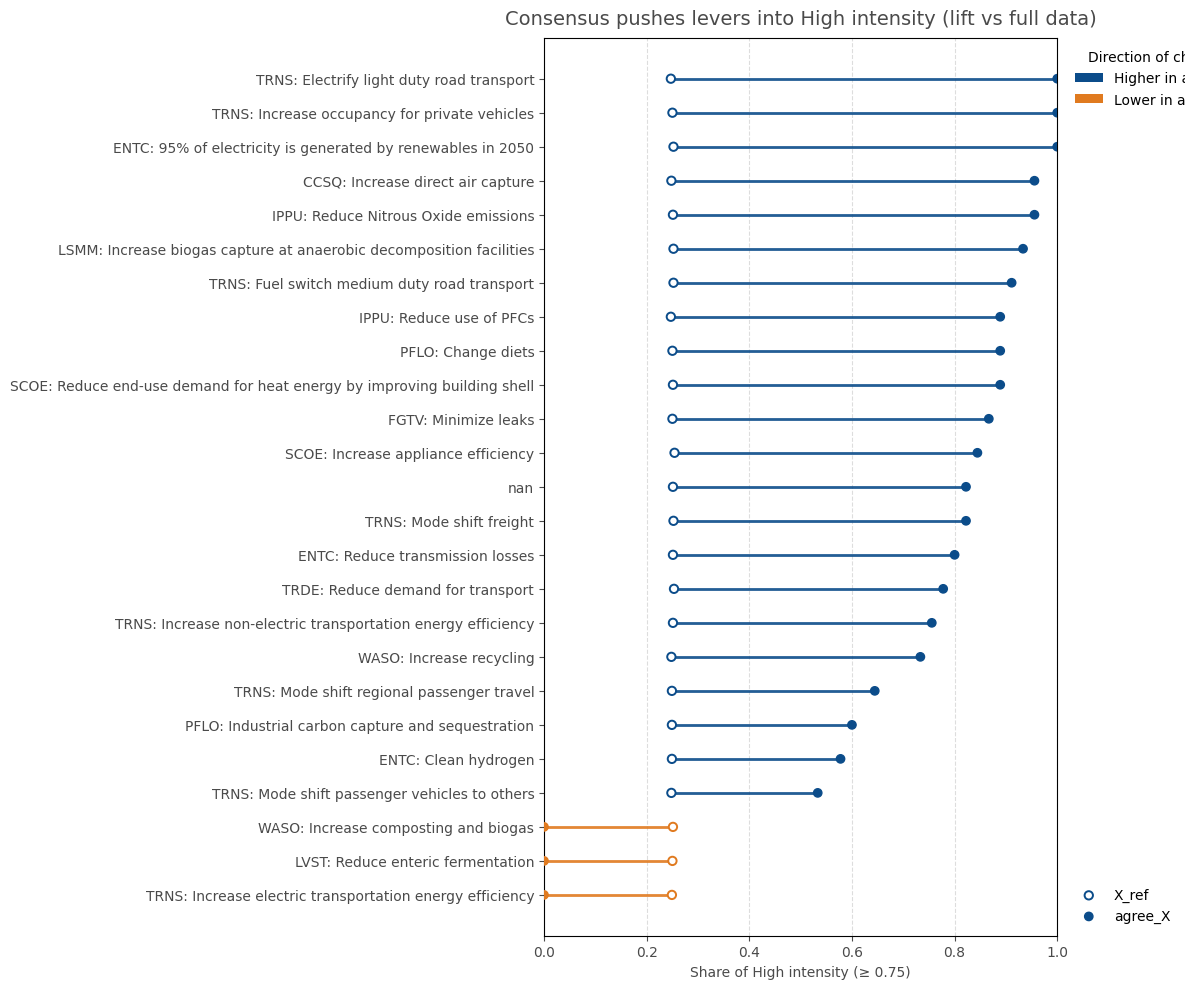

,share_ref,share_agree,delta
label,,,
TRNS: Electrify light duty road transport,24.7%,100.0%,75.3%
TRNS: Increase occupancy for private vehicles,25.0%,100.0%,75.0%
ENTC: 95% of electricity is generated by renewables in 2050,25.2%,100.0%,74.8%
CCSQ: Increase direct air capture,24.8%,95.6%,70.7%
IPPU: Reduce Nitrous Oxide emissions,25.1%,95.6%,70.4%
LSMM: Increase biogas capture at anaerobic decomposition facilities,25.2%,93.3%,68.1%
TRNS: Fuel switch medium duty road transport,25.2%,91.1%,65.9%
IPPU: Reduce use of PFCs,24.7%,88.9%,64.2%
PFLO: Change diets,25.0%,88.9%,63.9%


In [ ]:
# ============================================================
# Dumbbell "lift" chart: share of High (>=0.75) by lever
# Compares agree_X vs X_ref; shows top |delta| levers
# ============================================================

import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# ---- config ----
HIGH_THR = 0.75
MAX_LEVERS = 25       # top-N by absolute delta to display
TEXT_GRAY = "#4a4a4a"
plt.rcParams["font.family"] = "DejaVu Sans"

# Optional mapping like {7: "Increase occupancy", ...}
group_to_name = globals().get("group_to_name", {})

# Pretty label: turn "group_12_clean_h2" -> "clean_h2" (or mapped name if available)
def pretty_label(col: str) -> str:
    m = re.match(r"^group_(\d+)_?(.*)$", col)
    if not m:
        return col
    gid = int(m.group(1))
    rest = m.group(2)
    if group_to_name.get(gid):
        return group_to_name[gid]
    # if there was text after the number, use it; else fallback to "lever <gid>"
    return rest if rest else f"lever {gid}"

# Find lever columns group_<N> with N < 48 and present in both frames
def lever_cols_lt48(df_cols):
    out = []
    rx = re.compile(r"^group_(\d+)(?:_|$)")
    for c in df_cols:
        m = rx.match(c)
        if m and int(m.group(1)) < 48:
            out.append(c)
    return out

lever_cols = [c for c in lever_cols_lt48(agree_X.columns) if c in X_ref.columns]
if not lever_cols:
    raise ValueError("No lever columns (group_<N>, N<48) common to agree_X and X_ref.")

# Compute share of High for each lever in both datasets
share_ref   = pd.Series({c: (X_ref[c] >= HIGH_THR).mean() for c in lever_cols})
share_agree = pd.Series({c: (agree_X[c] >= HIGH_THR).mean() for c in lever_cols})
delta = (share_agree - share_ref).rename("delta")

# Build table & choose top levers by absolute delta
tbl = pd.DataFrame({
    "lever": lever_cols,
    "share_ref": share_ref.values,
    "share_agree": share_agree.values,
    "delta": delta.values,
})
tbl["label"] = tbl["lever"].apply(pretty_label)
tbl = tbl.reindex(tbl["delta"].abs().sort_values(ascending=False).index)

if MAX_LEVERS is not None and MAX_LEVERS > 0:
    tbl = tbl.head(MAX_LEVERS)

# ---- plot: dumbbell ----
fig, ax = plt.subplots(figsize=(12, max(6, 0.4 * len(tbl))))

y = np.arange(len(tbl))
ref_vals   = tbl["share_ref"].to_numpy()
agree_vals = tbl["share_agree"].to_numpy()
labels     = tbl["label"].tolist()
deltas     = tbl["delta"].to_numpy()

# Colors: blue when agree > ref, orange when agree < ref
pos_color = "#0B4C8A"
neg_color = "#E07A1F"
colors = np.where(deltas >= 0, pos_color, neg_color)

# Lines connecting ref -> agree
for i in range(len(tbl)):
    ax.hlines(y=i, xmin=ref_vals[i], xmax=agree_vals[i],
              color=colors[i], lw=2, alpha=0.9)

# Endpoints
ax.scatter(ref_vals,   y, s=36, facecolor="white", edgecolor=colors, linewidth=1.4, zorder=3, label="X_ref")
ax.scatter(agree_vals, y, s=36, facecolor=colors,   edgecolor=colors, linewidth=1.0, zorder=3, label="agree_X")

# Y labels (sorted by |delta|), gray font
ax.set_yticks(y)
ax.set_yticklabels(labels, color=TEXT_GRAY)

# X formatting
ax.set_xlim(0, 1)
ax.set_xlabel("Share of High intensity (≥ 0.75)", color=TEXT_GRAY)
ax.set_title("Consensus pushes levers into High intensity (lift vs full data)",
             fontsize=14, pad=10, color=TEXT_GRAY)

# Grid & aesthetics
ax.grid(axis="x", color="#dddddd", linestyle="--", linewidth=0.8)
ax.tick_params(axis="x", colors=TEXT_GRAY)
ax.tick_params(axis="y", colors=TEXT_GRAY)
ax.invert_yaxis()  # biggest deltas top

# Legend outside (no overlap)
legend_elems = [
    Patch(facecolor=pos_color, edgecolor="none", label="Higher in agree_X"),
    Patch(facecolor=neg_color, edgecolor="none", label="Lower in agree_X"),
]
leg1 = ax.legend(handles=legend_elems, title="Direction of change",
                 loc="upper left", bbox_to_anchor=(1.01, 1.0),
                 frameon=False, title_fontsize=10)
ax.add_artist(leg1)
ax.legend(loc="lower left", bbox_to_anchor=(1.01, 0.0), frameon=False, title=None)

plt.tight_layout()
plt.show()

# show the numeric table
display(tbl[["label", "share_ref", "share_agree", "delta"]].set_index("label").style.format("{:.1%}"))
